In [1]:
# Before writing any ML code, understand what is happening
# Machine Learning = teaching a computer to learn from examples
# Instead of telling it rules, you show it data and it figures out the rules itself

# Example:
# Old way (rule based): if email contains "free money" → spam
# ML way: show 10000 emails labelled spam/not spam → model learns the rules itself

# Three types of ML:
# 1. SUPERVISED LEARNING   → you give data AND correct answers
# 2. UNSUPERVISED LEARNING → you give data, model finds patterns itself  
# 3. REINFORCEMENT LEARNING → model learns by trial and error with rewards

print("Types of Machine Learning:")
print("1. Supervised   → Classification and Regression")
print("2. Unsupervised → Clustering and Dimensionality Reduction")
print("3. Reinforcement → Games, Robots, Autonomous systems")
print()
print("For your Document Assistant we use SUPERVISED LEARNING")
print("We show it documents with labels → it learns to classify new ones")

Types of Machine Learning:
1. Supervised   → Classification and Regression
2. Unsupervised → Clustering and Dimensionality Reduction
3. Reinforcement → Games, Robots, Autonomous systems

For your Document Assistant we use SUPERVISED LEARNING
We show it documents with labels → it learns to classify new ones


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Iris is the classic beginner ML dataset
# 150 flowers, 4 measurements each, 3 species
# Goal: predict which species a flower is based on measurements

iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = df["species"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSpecies distribution:")
print(df["species_name"].value_counts())

Dataset shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Species distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
# FEATURES = the input → what you feed the model
# LABELS   = the output → what the model predicts

# Features — the 4 measurements
X = df[iris.feature_names]

# Labels — the species
y = df["species"]

print("Features (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)
print()
print("Features — first 3 rows:")
print(X.head(3))
print()
print("Labels — first 3:")
print(y.head(3).values)
print()
print("X = what we know")
print("y = what we want to predict")

Features (X) shape: (150, 4)
Labels (y) shape: (150,)

Features — first 3 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2

Labels — first 3:
[0 0 0]

X = what we know
y = what we want to predict


In [4]:
from sklearn.model_selection import train_test_split

# You CANNOT test a model on the same data it trained on
# That's like giving students the exam answers during studying
# They will score 100% but learned nothing

# Split data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% goes to testing
    random_state=42     # ensures same split every time you run
)

print("Total data:", len(X))
print("Training data:", len(X_train), "→ model learns from this")
print("Testing data:", len(X_test), "→ model is evaluated on this")
print()
print("The model will NEVER see test data during training")
print("This gives us an honest measure of how well it learned")

Total data: 150
Training data: 120 → model learns from this
Testing data: 30 → model is evaluated on this

The model will NEVER see test data during training
This gives us an honest measure of how well it learned


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Linear Regression predicts a NUMBER
# Example: predict house price based on size, rooms, location
# It finds the best straight line through your data

# Simple example — predict petal width from petal length
X_simple = df[["petal length (cm)"]].values
y_simple = df["petal width (cm)"].values

X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create model
model = LinearRegression()

# Train it — this is where learning happens
model.fit(X_tr, y_tr)

# Predict on test data
predictions = model.predict(X_te)

# Measure error
mse = mean_squared_error(y_te, predictions)
rmse = np.sqrt(mse)

print("Linear Regression trained successfully")
print()
print("Example predictions vs actual:")
for i in range(5):
    print(f"  Predicted: {predictions[i]:.2f}  |  Actual: {y_te[i]:.2f}")
print()
print(f"Root Mean Squared Error: {rmse:.3f}")
print("Lower RMSE = better model")

Linear Regression trained successfully

Example predictions vs actual:
  Predicted: 1.59  |  Actual: 1.20
  Predicted: 0.35  |  Actual: 0.30
  Predicted: 2.49  |  Actual: 2.30
  Predicted: 1.50  |  Actual: 1.50
  Predicted: 1.63  |  Actual: 1.40

Root Mean Squared Error: 0.214
Lower RMSE = better model


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression predicts a CATEGORY not a number
# Despite the name it is a CLASSIFICATION algorithm
# Output: which class does this belong to?

X = df[iris.feature_names]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Measure accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression trained successfully")
print()
print("Predictions vs Actual:")
species_names = {0: "setosa", 1: "versicolor", 2: "virginica"}
for i in range(8):
    predicted = species_names[y_pred[i]]
    actual = species_names[y_test.values[i]]
    correct = "✓" if predicted == actual else "✗"
    print(f"  {correct} Predicted: {predicted:12} | Actual: {actual}")
print()
print(f"Accuracy: {accuracy * 100:.1f}%")

Logistic Regression trained successfully

Predictions vs Actual:
  ✓ Predicted: versicolor   | Actual: versicolor
  ✓ Predicted: setosa       | Actual: setosa
  ✓ Predicted: virginica    | Actual: virginica
  ✓ Predicted: versicolor   | Actual: versicolor
  ✓ Predicted: versicolor   | Actual: versicolor
  ✓ Predicted: setosa       | Actual: setosa
  ✓ Predicted: versicolor   | Actual: versicolor
  ✓ Predicted: virginica    | Actual: virginica

Accuracy: 100.0%


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# THIS IS HUGE
# You are now applying ML directly to your Document Assistant
# Given a piece of text → predict its category automatically

# Training data — documents with labels
documents = [
    ("AI is transforming healthcare and medicine", "technology"),
    ("Python programming is used for data science", "programming"),
    ("Machine learning models predict outcomes", "technology"),
    ("Neural networks process image recognition", "technology"),
    ("JavaScript is used for web development", "programming"),
    ("Deep learning requires powerful GPUs", "technology"),
    ("Java is an object oriented programming language", "programming"),
    ("Data structures and algorithms are fundamental", "programming"),
    ("Natural language processing understands text", "technology"),
    ("React and Vue are frontend frameworks", "programming"),
    ("Computer vision detects objects in images", "technology"),
    ("SQL databases store structured data efficiently", "programming"),
]

texts = [doc[0] for doc in documents]
labels = [doc[1] for doc in documents]

# Step 1 - Convert text to TF-IDF numbers
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)
y = labels

# Step 2 - Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3 - Train classifier
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Step 4 - Test it
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Document classifier accuracy: {accuracy * 100:.1f}%")

# Step 5 - Predict on brand new documents
new_docs = [
    "Pandas and NumPy are Python libraries",
    "Reinforcement learning trains AI agents",
    "CSS and HTML build web interfaces"
]

new_vectors = vectorizer.transform(new_docs)
predictions = clf.predict(new_vectors)

print("\nClassifying new documents:")
for doc, pred in zip(new_docs, predictions):
    print(f"  '{doc}'")
    print(f"   → Category: {pred}")
    print()

Document classifier accuracy: 33.3%

Classifying new documents:
  'Pandas and NumPy are Python libraries'
   → Category: programming

  'Reinforcement learning trains AI agents'
   → Category: technology

  'CSS and HTML build web interfaces'
   → Category: programming



In [8]:
# A Decision Tree makes decisions exactly like a human would
# It asks a series of yes/no questions to reach an answer

# Example — is this email spam?
# Question 1: Does it contain "free money"?  YES → likely spam
#                                             NO  → ask next question
# Question 2: Does it contain "click here"?  YES → likely spam
#                                             NO  → probably not spam

# The tree learns WHICH questions to ask and in WHAT ORDER
# by analyzing your training data

# Terminology:
# ROOT NODE    → the first question (most important split)
# INTERNAL NODE → questions in the middle
# LEAF NODE    → final answer (the prediction)
# DEPTH        → how many questions deep the tree goes

print("Decision Tree Terminology:")
print("Root Node    → First and most important question")
print("Internal Node → Questions in the middle of the tree")
print("Leaf Node    → Final prediction at the bottom")
print("Depth        → How many levels of questions")
print()
print("Advantage: Easy to understand and explain")
print("Disadvantage: Can overfit if tree gets too deep")

Decision Tree Terminology:
Root Node    → First and most important question
Internal Node → Questions in the middle of the tree
Leaf Node    → Final prediction at the bottom
Depth        → How many levels of questions

Advantage: Easy to understand and explain
Disadvantage: Can overfit if tree gets too deep


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train Decision Tree
dt = DecisionTreeClassifier(
    max_depth=3,        # limit tree depth to prevent overfitting
    random_state=42
)
dt.fit(X_train, y_train)

# Predict and evaluate
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Results:")
print(f"Accuracy: {accuracy * 100:.1f}%")
print()
print("The tree asked these questions to classify flowers:")
print("Question 1: Is petal length <= 2.45cm?")
print("  YES → Setosa (done)")
print("  NO  → Ask next question")
print("Question 2: Is petal width <= 1.75cm?")
print("  YES → Versicolor")
print("  NO  → Virginica")

Decision Tree Results:
Accuracy: 100.0%

The tree asked these questions to classify flowers:
Question 1: Is petal length <= 2.45cm?
  YES → Setosa (done)
  NO  → Ask next question
Question 2: Is petal width <= 1.75cm?
  YES → Versicolor
  NO  → Virginica


Feature Importances:
          feature  importance
petal length (cm)    0.934626
 petal width (cm)    0.065374
 sepal width (cm)    0.000000
sepal length (cm)    0.000000

Higher importance = more useful for making predictions
Lower importance = less useful, could potentially be removed


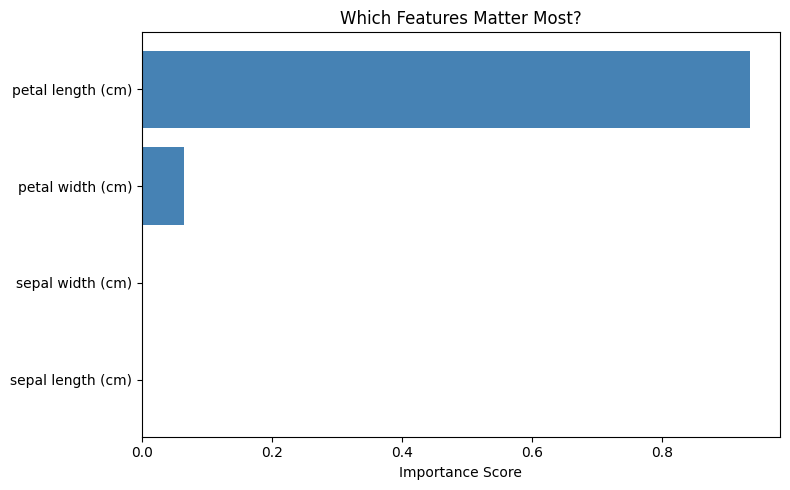

In [12]:
# One of the best things about Decision Trees
# They tell you WHICH features mattered most for predictions
# This is called Feature Importance

importances = dt.feature_importances_
feature_names = iris.feature_names

# Create a DataFrame to see clearly
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Feature Importances:")
print(importance_df.to_string(index=False))
print()
print("Higher importance = more useful for making predictions")
print("Lower importance = less useful, could potentially be removed")

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Which Features Matter Most?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

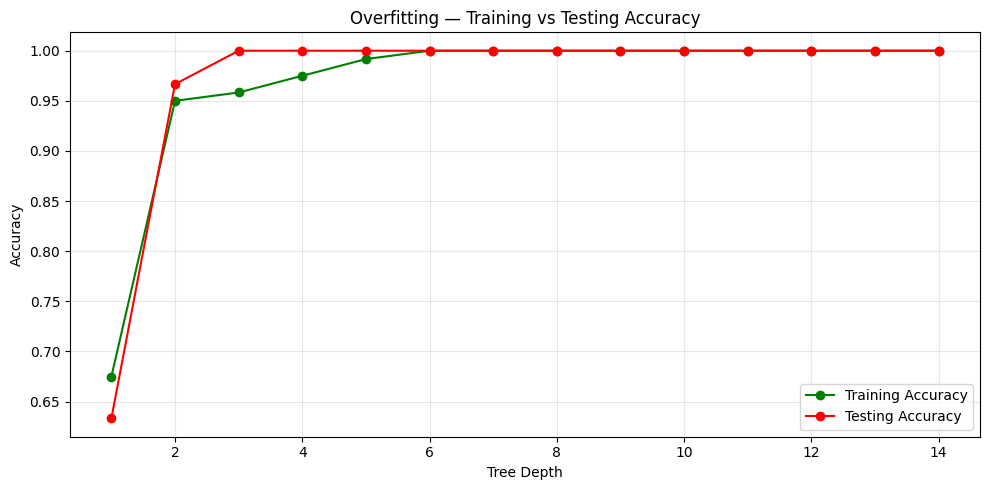

Notice: Training accuracy keeps going up
But Testing accuracy peaks then drops or stays flat
That gap = overfitting


In [13]:
# Decision Trees overfit easily if you let them grow too deep
# A very deep tree memorizes training data perfectly
# but fails badly on new data

# Let's prove this

train_accuracies = []
test_accuracies = []
depths = range(1, 15)

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, dt_temp.predict(X_train))
    test_acc = accuracy_score(y_test, dt_temp.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accuracies, label="Training Accuracy", marker="o", color="green")
plt.plot(depths, test_accuracies, label="Testing Accuracy", marker="o", color="red")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting — Training vs Testing Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: Training accuracy keeps going up")
print("But Testing accuracy peaks then drops or stays flat")
print("That gap = overfitting")

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest = many Decision Trees working together
# Each tree sees a random subset of data and features
# Final prediction = majority vote across all trees

# Why is this better?
# One tree can overfit. But 100 trees each making different mistakes
# tend to cancel each other out → much more accurate and stable

rf = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=3,        # depth of each tree
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Compare with single Decision Tree
accuracy_dt = accuracy_score(y_test, dt.predict(X_test))

print("Comparison:")
print(f"Single Decision Tree accuracy: {accuracy_dt * 100:.1f}%")
print(f"Random Forest accuracy:        {accuracy_rf * 100:.1f}%")
print()
print("Random Forest wins because many imperfect trees")
print("together make better decisions than one tree alone")

Comparison:
Single Decision Tree accuracy: 100.0%
Random Forest accuracy:        100.0%

Random Forest wins because many imperfect trees
together make better decisions than one tree alone


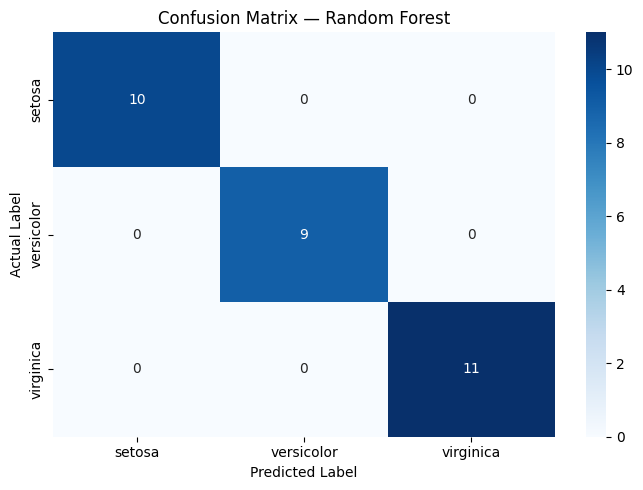

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Accuracy alone is not enough
# A confusion matrix shows EXACTLY where the model is right and wrong

y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

# Visualize
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Detailed report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Upgrade your document classifier from Logistic Regression
# to Random Forest — more powerful, more accurate

documents = [
    ("AI is transforming healthcare and medicine", "technology"),
    ("Python programming is used for data science", "programming"),
    ("Machine learning models predict outcomes", "technology"),
    ("Neural networks process image recognition", "technology"),
    ("JavaScript is used for web development", "programming"),
    ("Deep learning requires powerful GPUs", "technology"),
    ("Java is an object oriented programming language", "programming"),
    ("Data structures and algorithms are fundamental", "programming"),
    ("Natural language processing understands text", "technology"),
    ("React and Vue are frontend frameworks", "programming"),
    ("Computer vision detects objects in images", "technology"),
    ("SQL databases store structured data efficiently", "programming"),
    ("Transformers are the backbone of modern AI", "technology"),
    ("Git and GitHub are version control tools", "programming"),
    ("Reinforcement learning trains intelligent agents", "technology"),
    ("Docker containers package applications reliably", "programming"),
]

texts = [doc[0] for doc in documents]
labels = [doc[1] for doc in documents]

# TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)
y = labels

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest classifier
rf_doc = RandomForestClassifier(n_estimators=100, random_state=42)
rf_doc.fit(X_train, y_train)

# Evaluate
y_pred = rf_doc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Document Classifier Accuracy: {accuracy * 100:.1f}%")
print()
print(classification_report(y_test, y_pred))

# Test on new documents
new_docs = [
    "TensorFlow and PyTorch are deep learning frameworks",
    "APIs connect different software applications together",
    "Kubernetes orchestrates containerized applications",
    "Large language models generate human like text"
]

new_vectors = vectorizer.transform(new_docs)
predictions = rf_doc.predict(new_vectors)

print("Classifying new documents:")
for doc, pred in zip(new_docs, predictions):
    print(f"  '{doc}'")
    print(f"   → {pred}")
    print()

Document Classifier Accuracy: 75.0%

              precision    recall  f1-score   support

 programming       0.50      1.00      0.67         1
  technology       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

Classifying new documents:
  'TensorFlow and PyTorch are deep learning frameworks'
   → programming

  'APIs connect different software applications together'
   → programming

  'Kubernetes orchestrates containerized applications'
   → programming

  'Large language models generate human like text'
   → technology



In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# KNN = K-Nearest Neighbours
# The simplest ML algorithm conceptually
# To classify a new point — find the K closest training points
# and take the majority vote

# Example:
# New document arrives
# Find 5 most similar documents from training data
# 4 are "technology", 1 is "programming"
# Prediction → "technology"

# Load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Try different values of K
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    results.append({"K": k, "Accuracy": acc})
    print(f"K={k:2d}  →  Accuracy: {acc*100:.1f}%")

print()
best = max(results, key=lambda x: x["Accuracy"])
print(f"Best K: {best['K']} with accuracy {best['Accuracy']*100:.1f}%")

K= 1  →  Accuracy: 100.0%
K= 3  →  Accuracy: 100.0%
K= 5  →  Accuracy: 100.0%
K= 7  →  Accuracy: 96.7%
K= 9  →  Accuracy: 100.0%
K=11  →  Accuracy: 100.0%
K=15  →  Accuracy: 100.0%

Best K: 1 with accuracy 100.0%


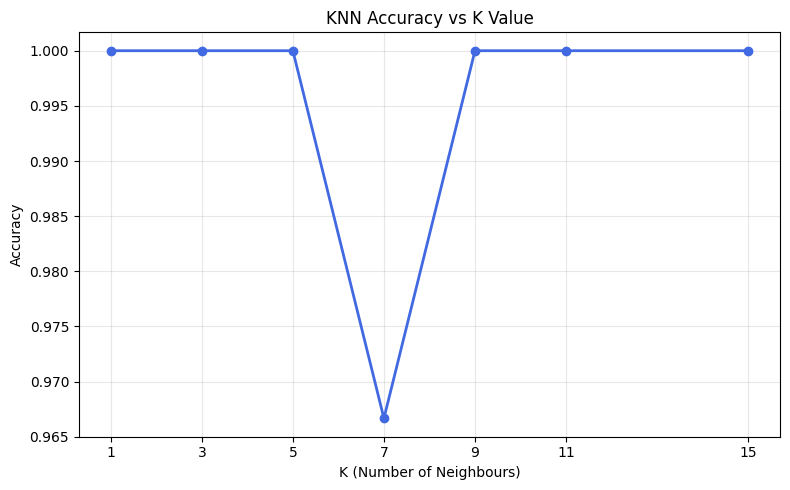

Too small K → overfitting (memorizes training data)
Too large K → underfitting (too generalized)
Sweet spot → usually K=5 or K=7 for most problems


In [18]:
import matplotlib.pyplot as plt

k_vals = [r["K"] for r in results]
accuracies = [r["Accuracy"] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(k_vals, accuracies, marker="o", color="royalblue", linewidth=2)
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K (Number of Neighbours)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)
plt.tight_layout()
plt.show()

print("Too small K → overfitting (memorizes training data)")
print("Too large K → underfitting (too generalized)")
print("Sweet spot → usually K=5 or K=7 for most problems")

In [19]:
from sklearn.svm import SVC

# SVM = Support Vector Machine
# Finds the BEST boundary between classes
# Not just any boundary — the one with maximum margin

# Imagine two groups of dots on a graph
# Many lines could separate them
# SVM finds the line that is FURTHEST from both groups
# This maximum margin makes it more robust on new data

# The dots closest to the boundary are called SUPPORT VECTORS
# They are the critical points that define the boundary

# SVM with linear boundary
svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train, y_train)
acc_linear = accuracy_score(y_test, svm_linear.predict(X_test))
print(f"SVM Linear kernel accuracy:  {acc_linear*100:.1f}%")

# SVM with RBF kernel — handles non-linear boundaries
svm_rbf = SVC(kernel="rbf", random_state=42)
svm_rbf.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))
print(f"SVM RBF kernel accuracy:     {acc_rbf*100:.1f}%")

print()
print("Linear kernel → good when classes are linearly separable")
print("RBF kernel    → good when boundary is complex and curved")

SVM Linear kernel accuracy:  100.0%
SVM RBF kernel accuracy:     100.0%

Linear kernel → good when classes are linearly separable
RBF kernel    → good when boundary is complex and curved


In [20]:
from sklearn.model_selection import cross_val_score

# Problem with single train/test split:
# Results depend on which 20% ended up in test set
# You might get lucky or unlucky with the split

# Cross Validation solves this
# It splits data into K equal parts (folds)
# Trains K times, each time using a different fold as test set
# Final score = average across all K runs
# Much more reliable estimate of true performance

# 5-Fold Cross Validation on Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# cv=5 means 5 folds
scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

print("5-Fold Cross Validation Results:")
print(f"Scores per fold: {scores.round(3)}")
print(f"Mean accuracy:   {scores.mean()*100:.1f}%")
print(f"Std deviation:   {scores.std()*100:.1f}%")
print()
print("Low std deviation = consistent, reliable model")
print("High std deviation = model performance varies a lot = unreliable")

5-Fold Cross Validation Results:
Scores per fold: [0.967 0.967 0.933 0.967 1.   ]
Mean accuracy:   96.7%
Std deviation:   2.1%

Low std deviation = consistent, reliable model
High std deviation = model performance varies a lot = unreliable


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import pandas as pd

# Compare ALL algorithms on the same data
# This is exactly what ML engineers do in real projects
# Try everything, keep what works best

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree":       DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
    "SVM Linear":          SVC(kernel="linear"),
    "SVM RBF":             SVC(kernel="rbf"),
}

results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    results.append({
        "Model": name,
        "Mean Accuracy": f"{scores.mean()*100:.1f}%",
        "Std Dev": f"{scores.std()*100:.1f}%",
        "Min": f"{scores.min()*100:.1f}%",
        "Max": f"{scores.max()*100:.1f}%"
    })

df_results = pd.DataFrame(results)
print("Model Comparison — 5-Fold Cross Validation:")
print(df_results.to_string(index=False))

Model Comparison — 5-Fold Cross Validation:
              Model Mean Accuracy Std Dev   Min    Max
Logistic Regression         97.3%    2.5% 93.3% 100.0%
      Decision Tree         97.3%    2.5% 93.3% 100.0%
      Random Forest         96.7%    2.1% 93.3% 100.0%
          KNN (k=5)         97.3%    2.5% 93.3% 100.0%
         SVM Linear         98.0%    1.6% 96.7% 100.0%
            SVM RBF         96.7%    2.1% 93.3% 100.0%


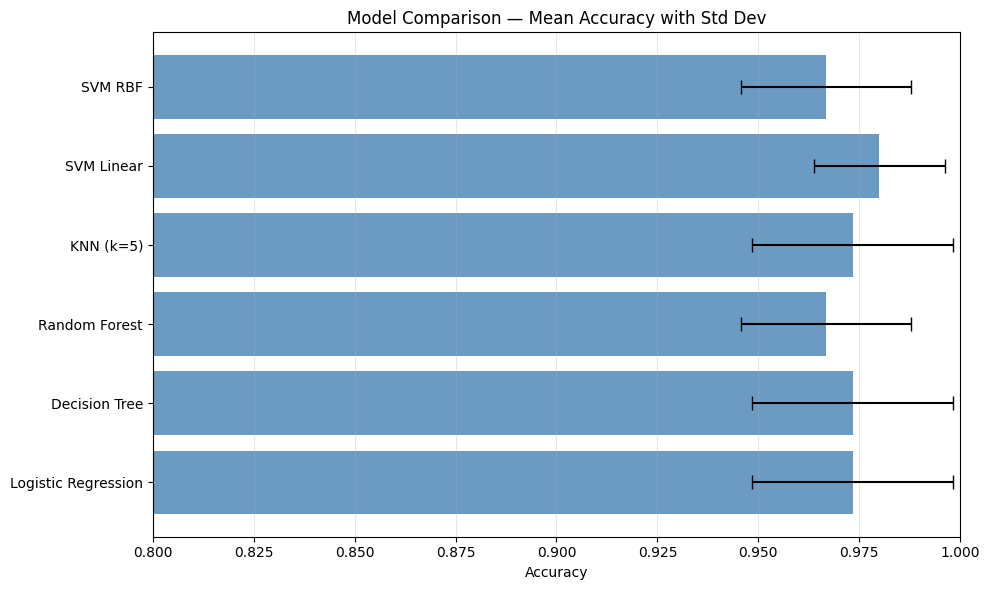

Best model: SVM Linear
Accuracy:   98.0%


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

model_names = list(models.keys())
mean_scores = []
std_scores = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

# Plot with error bars showing standard deviation
plt.figure(figsize=(10, 6))
bars = plt.barh(
    model_names,
    mean_scores,
    xerr=std_scores,
    color="steelblue",
    alpha=0.8,
    capsize=5
)
plt.xlabel("Accuracy")
plt.title("Model Comparison — Mean Accuracy with Std Dev")
plt.xlim(0.8, 1.0)
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

best_idx = np.argmax(mean_scores)
print(f"Best model: {model_names[best_idx]}")
print(f"Accuracy:   {mean_scores[best_idx]*100:.1f}%")

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import pandas as pd

# Run all models on YOUR document classification problem
# Find the best algorithm for your specific use case

documents = [
    ("AI is transforming healthcare and medicine", "technology"),
    ("Python programming is used for data science", "programming"),
    ("Machine learning models predict outcomes", "technology"),
    ("Neural networks process image recognition", "technology"),
    ("JavaScript is used for web development", "programming"),
    ("Deep learning requires powerful GPUs", "technology"),
    ("Java is an object oriented programming language", "programming"),
    ("Data structures and algorithms are fundamental", "programming"),
    ("Natural language processing understands text", "technology"),
    ("React and Vue are frontend frameworks", "programming"),
    ("Computer vision detects objects in images", "technology"),
    ("SQL databases store structured data efficiently", "programming"),
    ("Transformers are the backbone of modern AI", "technology"),
    ("Git and GitHub are version control tools", "programming"),
    ("Reinforcement learning trains intelligent agents", "technology"),
    ("Docker containers package applications reliably", "programming"),
    ("ChatGPT uses large language models for text", "technology"),
    ("Python functions and classes organize code well", "programming"),
]

texts = [doc[0] for doc in documents]
labels = [doc[1] for doc in documents]

# Use Pipeline — combines TF-IDF and model into one object
# This is the professional way to build ML pipelines

models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=200))
    ]),
    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "KNN": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", KNeighborsClassifier(n_neighbors=3))
    ]),
    "SVM": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", SVC(kernel="linear"))
    ]),
}

print("Document Classifier — Model Comparison:")
print()

best_model = None
best_score = 0
best_name = ""

for name, pipeline in models.items():
    scores = cross_val_score(pipeline, texts, labels, cv=3, scoring="accuracy")
    mean = scores.mean()
    print(f"{name:22} → {mean*100:.1f}% accuracy")
    
    if mean > best_score:
        best_score = mean
        best_name = name
        best_model = pipeline

print()
print(f"Best model for your project: {best_name}")
print(f"Accuracy: {best_score*100:.1f}%")

# Train best model on all data and test on new documents
best_model.fit(texts, labels)

new_docs = [
    "TensorFlow builds and trains neural networks",
    "Linux terminal commands manage the file system",
    "BERT is a transformer based language model",
    "Object oriented programming uses classes and objects"
]

predictions = best_model.predict(new_docs)
print("\nFinal classifier predictions:")
for doc, pred in zip(new_docs, predictions):
    print(f"  '{doc}'")
    print(f"   → {pred}")
    print()

Document Classifier — Model Comparison:

Logistic Regression    → 77.8% accuracy
Random Forest          → 66.7% accuracy
KNN                    → 50.0% accuracy
SVM                    → 77.8% accuracy

Best model for your project: Logistic Regression
Accuracy: 77.8%

Final classifier predictions:
  'TensorFlow builds and trains neural networks'
   → technology

  'Linux terminal commands manage the file system'
   → technology

  'BERT is a transformer based language model'
   → programming

  'Object oriented programming uses classes and objects'
   → programming



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Every ML model has settings called hyperparameters
# These are values YOU set before training — not learned from data

# Example hyperparameters for Random Forest:
# n_estimators → how many trees
# max_depth    → how deep each tree can grow
# min_samples_split → minimum samples needed to split a node

# Most people just use default settings and hope for the best
# Real engineers TUNE these settings to find the best combination

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Default settings
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
acc_default = accuracy_score(y_test, rf_default.predict(X_test))

print("Default Random Forest settings:")
print(f"n_estimators: {rf_default.n_estimators}")
print(f"max_depth:    {rf_default.max_depth}")
print(f"Accuracy:     {acc_default*100:.1f}%")
print()
print("Can we do better by tuning these settings?")

Default Random Forest settings:
n_estimators: 100
max_depth:    None
Accuracy:     100.0%

Can we do better by tuning these settings?


In [25]:
# Before using automated tools
# understand what each hyperparameter does manually

results = []

for n_trees in [10, 50, 100, 200]:
    for depth in [2, 3, 5, None]:
        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42
        )
        rf.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf.predict(X_test))
        results.append({
            "n_estimators": n_trees,
            "max_depth": str(depth),
            "accuracy": acc
        })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("accuracy", ascending=False)

print("Manual Hyperparameter Search Results:")
print(df_results.head(10).to_string(index=False))
print()
best = df_results.iloc[0]
print(f"Best combination:")
print(f"  n_estimators: {best['n_estimators']}")
print(f"  max_depth:    {best['max_depth']}")
print(f"  accuracy:     {best['accuracy']*100:.1f}%")

Manual Hyperparameter Search Results:
 n_estimators max_depth  accuracy
           10         2       1.0
           10         3       1.0
           10         5       1.0
           10      None       1.0
           50         2       1.0
           50         3       1.0
           50         5       1.0
           50      None       1.0
          100         2       1.0
          100         3       1.0

Best combination:
  n_estimators: 10
  max_depth:    2
  accuracy:     100.0%


In [26]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV automates what you just did manually
# It tries EVERY combination of hyperparameters
# and uses cross validation to find the best

# Define the grid — all combinations to try
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5, None],
    "min_samples_split": [2, 5, 10]
}

# This will try 3 × 4 × 3 = 36 combinations
# Each with 5-fold cross validation = 180 model fits total

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,      # use all CPU cores for speed
    verbose=1       # print progress
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(grid_search.best_params_)
print(f"\nBest Cross Validation Accuracy: {grid_search.best_score_*100:.1f}%")

# Test best model on held out test set
best_model = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test Set Accuracy: {test_acc*100:.1f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters Found:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross Validation Accuracy: 95.0%
Test Set Accuracy: 100.0%


In [27]:
from sklearn.model_selection import RandomizedSearchCV

# GridSearchCV tries ALL combinations — can be very slow
# RandomizedSearchCV tries a RANDOM SAMPLE of combinations
# Much faster, often finds equally good results

param_distributions = {
    "n_estimators": [10, 50, 100, 200, 500],
    "max_depth": [2, 3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions,
    n_iter=20,          # try 20 random combinations
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest CV Accuracy: {random_search.best_score_*100:.1f}%")

test_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f"Test Accuracy:    {test_acc*100:.1f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters Found:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best CV Accuracy: 95.8%
Test Accuracy:    100.0%


In [28]:
from sklearn.model_selection import RandomizedSearchCV

# GridSearchCV tries ALL combinations — can be very slow
# RandomizedSearchCV tries a RANDOM SAMPLE of combinations
# Much faster, often finds equally good results

param_distributions = {
    "n_estimators": [10, 50, 100, 200, 500],
    "max_depth": [2, 3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions,
    n_iter=20,          # try 20 random combinations
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest CV Accuracy: {random_search.best_score_*100:.1f}%")

test_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f"Test Accuracy:    {test_acc*100:.1f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters Found:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best CV Accuracy: 95.8%
Test Accuracy:    100.0%


Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



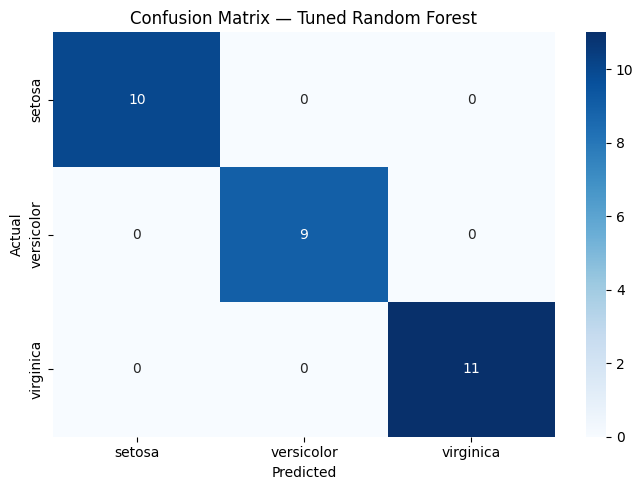

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use best model from grid search
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Full classification report
print("Full Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix — Tuned Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [31]:
import joblib
import os

# After all that training and tuning
# you need to SAVE your model
# Otherwise you retrain from scratch every time

# Save the model
joblib.dump(best_rf, "best_model.pkl")
print("Model saved as best_model.pkl")

# Save the model size
size = os.path.getsize("best_model.pkl")
print(f"File size: {size/1024:.1f} KB")

# Load it back
loaded_model = joblib.load("best_model.pkl")
print("\nModel loaded successfully")

# Verify it works exactly the same
y_pred_loaded = loaded_model.predict(X_test)
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"Loaded model accuracy: {acc_loaded*100:.1f}%")
print("Identical to original — model saved and loaded correctly")

Model saved as best_model.pkl
File size: 61.0 KB

Model loaded successfully
Loaded model accuracy: 100.0%
Identical to original — model saved and loaded correctly


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import joblib

# Tune your document classifier properly
# Find the best settings for YOUR specific use case

documents = [
    ("AI is transforming healthcare and medicine", "technology"),
    ("Python programming is used for data science", "programming"),
    ("Machine learning models predict outcomes", "technology"),
    ("Neural networks process image recognition", "technology"),
    ("JavaScript is used for web development", "programming"),
    ("Deep learning requires powerful GPUs", "technology"),
    ("Java is an object oriented programming language", "programming"),
    ("Data structures and algorithms are fundamental", "programming"),
    ("Natural language processing understands text", "technology"),
    ("React and Vue are frontend frameworks", "programming"),
    ("Computer vision detects objects in images", "technology"),
    ("SQL databases store structured data efficiently", "programming"),
    ("Transformers are the backbone of modern AI", "technology"),
    ("Git and GitHub are version control tools", "programming"),
    ("Reinforcement learning trains intelligent agents", "technology"),
    ("Docker containers package applications reliably", "programming"),
    ("ChatGPT uses large language models for text", "technology"),
    ("Python functions and classes organize code well", "programming"),
]

texts = [doc[0] for doc in documents]
labels = [doc[1] for doc in documents]

# Pipeline with TF-IDF + SVM
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", SVC())
])

# Tune both TF-IDF settings AND SVM settings together
param_grid = {
    "tfidf__max_features": [50, 100, None],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__kernel": ["linear", "rbf"],
    "clf__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1
)

grid_search.fit(texts, labels)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Accuracy:   {grid_search.best_score_*100:.1f}%")

# Save the complete tuned pipeline
joblib.dump(grid_search.best_estimator_, "document_classifier.pkl")
print("\nTuned document classifier saved as document_classifier.pkl")

# Load and test
classifier = joblib.load("document_classifier.pkl")

new_docs = [
    "PyTorch builds deep learning models efficiently",
    "Kubernetes manages containerized cloud applications",
    "BERT and GPT are transformer language models",
    "Binary search trees organize data hierarchically"
]

predictions = classifier.predict(new_docs)
print("\nTuned classifier predictions:")
for doc, pred in zip(new_docs, predictions):
    print(f"  '{doc}'")
    print(f"   → {pred}")
    print()

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters: {'clf__C': 0.1, 'clf__kernel': 'linear', 'tfidf__max_features': 50, 'tfidf__ngram_range': (1, 1)}
Best Accuracy:   77.8%

Tuned document classifier saved as document_classifier.pkl

Tuned classifier predictions:
  'PyTorch builds deep learning models efficiently'
   → technology

  'Kubernetes manages containerized cloud applications'
   → programming

  'BERT and GPT are transformer language models'
   → technology

  'Binary search trees organize data hierarchically'
   → programming

